In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import numpy as np
from tensorflow.keras.preprocessing import image
import zipfile

In [ ]:
tf.random.set_seed(42)
print("TensorFlow version", tf.__version__)


TensorFlow version 2.19.0


*Download Dataset From Kaggle.com*

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:

with zipfile.ZipFile('face-mask-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall(".")

In [ ]:
base_dir = "data"
print("DataSets Folder: ", os.listdir(base_dir))



DataSets Folder:  ['with_mask', 'without_mask']


In [ ]:
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)
train_data = datagen.flow_from_directory(
    base_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    subset='training',
    seed = 42)


Found 6043 images belonging to 2 classes.


In [ ]:
test_data = datagen.flow_from_directory(
    base_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    subset='validation',
    seed = 42)

Found 1510 images belonging to 2 classes.


In [ ]:
#Creating the CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,3,activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(16,3,activation='relu'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dropout(0.3), #used for preventing overfitting
    tf.keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 106, 106, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 51, 51, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,281 (9.90 MB)

 Trainable params: 2,595,281 (9.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(train_data,epochs=5,validation_data=test_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
 12/189 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.5492 - loss: 0.7309

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.7896 - loss: 0.4501 - val_accuracy: 0.8993 - val_loss: 0.2567
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.8984 - loss: 0.2481 - val_accuracy: 0.9325 - val_loss: 0.1811
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.9130 - loss: 0.2100 - val_accuracy: 0.9397 - val_loss: 0.1665
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.9361 - loss: 0.1596 - val_accuracy: 0.9450 - val_loss: 0.1621
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.9495 - loss: 0.1368 - val_accuracy: 0.9609 - val_loss: 0.1563


In [ ]:
#Evaluate
loss,accuracy=model.evaluate(test_data)
print("Loss: ",loss)
print("Accuracy: ",accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9670 - loss: 0.1322
Loss:  0.15629950165748596
Accuracy:  0.9609271287918091


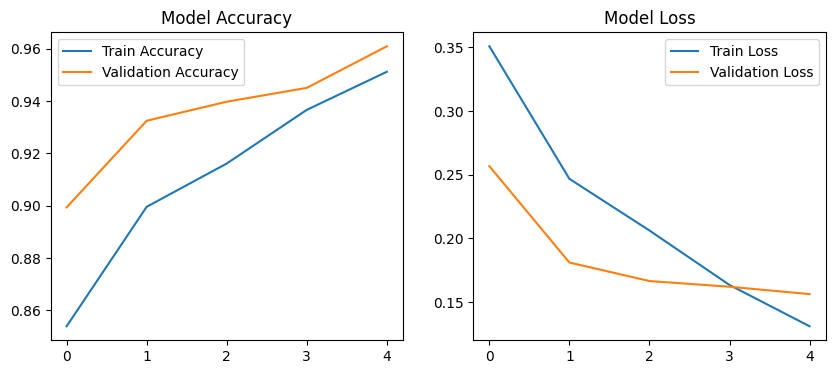

In [ ]:
#plot accuracy and loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.legend()
plt.title('Model Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


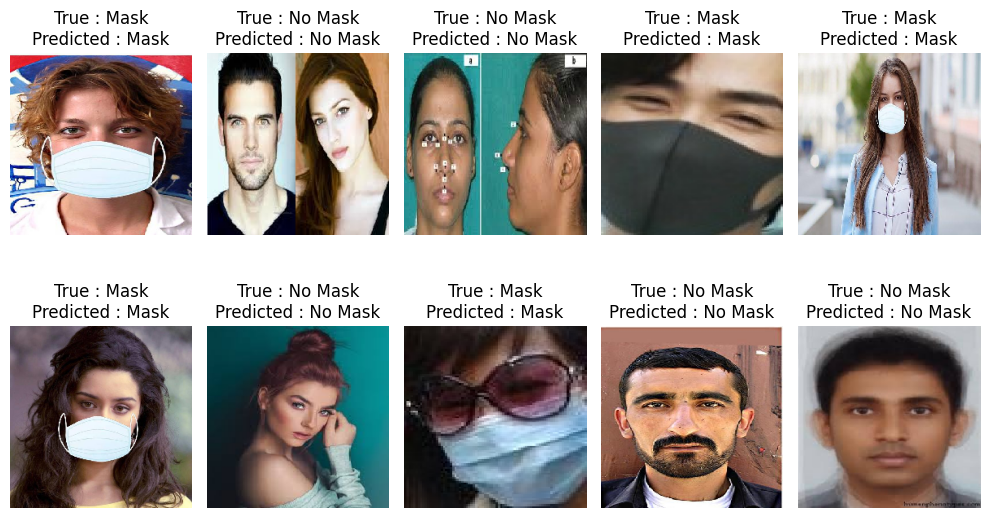

In [ ]:
images,labels = next(test_data)
predictions = model.predict(images)
plt.figure(figsize=(10,6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(images[i])
  true_label="Mask" if labels[i] == 0 else "No Mask"
  pred_label= "Mask" if predictions[i] < 0.5 else "No Mask"
  plt.title(f"True : {true_label}\nPredicted : {pred_label}")
  plt.axis('off')
plt.tight_layout()
plt.show()

Saving face1.jpg to face1.jpg
File Uploaded : face1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction:  No Mask
Confidence:  99.99903 %


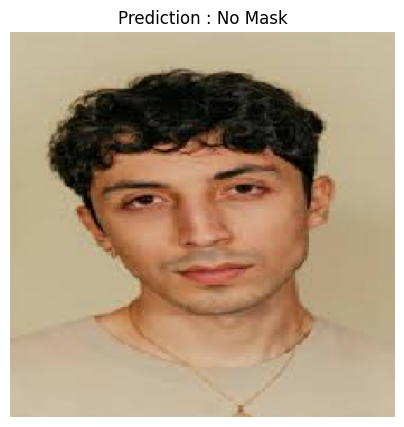

In [ ]:
from google.colab import files
uploaded=files.upload()
for fn in uploaded.keys():
  img_path=fn
  print("File Uploaded :", img_path)
  img=image.load_img(img_path,target_size=(224,224))
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)/255.0

  predict=model.predict(img_array)[0][0]
  label="Mask" if predict < 0.5 else "No Mask"
  print("Prediction: ",label)
  print("Confidence: ",100*(1-predict) if predict < 0.5 else 100*predict,"%")

  plt.figure(figsize=(5,5))
  plt.title(f"Prediction : {label}")
  plt.axis("off")
  plt.imshow(img)
  plt.show()